# Device math

> Call one `aether::math` function the same way from host code or a GPU
> kernel -- same name, same source line, either way.

**Time:** ~6 min · **Runs on:** CPU, GPU switch · **You need:**
[One array, two machines](01_one_array_two_machines)

In [1]:
%run ../_shared/setup.py

running on: cpu


`aether::math` wraps the host and device math library behind one name
per function -- the same call compiles unchanged whether this file
builds as host C++ or as a `.cu`. `sincos` is one of them:

In [2]:
print(run_cpp(r"""
    double s = 0.0, c = 0.0;
    aether::math::sincos(0.5, &s, &c);
    std::printf("sin=%.6f cos=%.6f\n", s, c);
"""))

sin=0.479426 cos=0.877583



Same call, same source line, on a host build or a device one.

No dedicated "CDF" function exists -- the standard normal CDF
(cumulative distribution function) is just `erfc` composed with ordinary
arithmetic:

In [3]:
print(run_cpp(r"""
    auto phi = [](double x) { return 0.5 * aether::math::erfc(-x / std::sqrt(2.0)); };
    std::printf("phi(0.0) = %.6f\n", phi(0.0));
""", includes=("<cmath>",)))

phi(0.0) = 0.500000



`0.5 * erfc(-x / sqrt(2))` is the whole function -- no bespoke
"statistics" module anywhere in the library.

## What you will build (the picture)

The curve the cell above just computed, point by point:

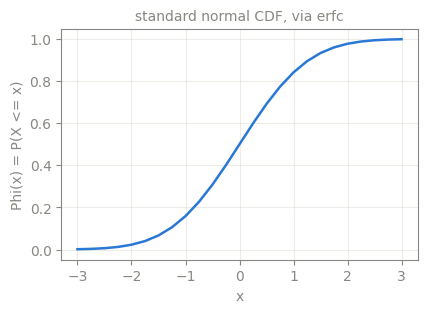

In [4]:
import matplotlib.pyplot as plt
plot_style()

out = run_cpp(r"""
    auto phi = [](double x) { return 0.5 * aether::math::erfc(-x / std::sqrt(2.0)); };
    for (double x = -3.0; x <= 3.0001; x += 0.25)
        std::printf("D,%.4f,%.6f\n", x, phi(x));
""", includes=("<cmath>",))
_, curve_rows = split_data(out)
xs = [float(r[0]) for r in curve_rows]
ys = [float(r[1]) for r in curve_rows]

fig, ax = plt.subplots(figsize=(4.6, 3))
ax.plot(xs, ys, color="#2a78d6", lw=1.8)
ax.set_xlabel("x"); ax.set_ylabel("Phi(x) = P(X <= x)")
ax.set_title("standard normal CDF, via erfc", color="#898781", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

The exact same call compiles unchanged with `nvcc` on a GPU machine --
same name, same source line, either way.

## What just happened

- Every `aether::math::*` name dispatches by argument type (`float` vs
  `double`), and in CUDA mode by compile pass too (device intrinsic vs
  `std::`) -- same call, same source line, either way.
- `sincos` writes two outputs through pointers; the standard normal CDF
  is just `0.5 * erfc(-x / sqrt(2))`, ordinary arithmetic over one
  library call.
- `hypot`, `exp` and the rest of `aether::math` all follow the same
  one-call, host-or-device pattern.

## Try this

Change `phi(0.0)` in the cell above to `phi(1.0)` (or any other `x`) and
re-run -- compare the printed value against the curve below.

## Next

[Your own device function and kernel](04_your_own_device_function) --
write a function once and call it from a CPU loop or a GPU kernel.
*Deeper:* [C++ API reference](../api/api_reference.rst) for the full
`aether::math` surface.

## Going deeper (optional): two honest differences from NumPy

`aether::math::sign` and `round`/`rint` are documented to depart from
NumPy on purpose: `sign(NaN)` is `0` here (NumPy's `np.sign(nan)` is
`nan`), and `aether::math::round` is C's round-half-away-from-zero
(NumPy's `np.round` is `rint`, round-half-to-even). aether's own test
suite checks host against device: exact functions match bit for bit, but
*transcendentals* -- functions like `erf`/`sincos` computed by a series
or algorithm, not one hardware instruction -- only have to land within
each platform's own documented accuracy, not identical digits between
host and device.

In [5]:
print(run_cpp(r"""
    std::printf("sign(nan) = %.1f   round(2.5) = %.1f   rint(2.5) = %.1f\n",
                 aether::math::sign(std::numeric_limits<double>::quiet_NaN()),
                 aether::math::round(2.5), aether::math::rint(2.5));
""", includes=("<limits>",)))

sign(nan) = 0.0   round(2.5) = 3.0   rint(2.5) = 2.0

